In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import shutil
import random
from tqdm import tqdm

# Set paths
source_path = '/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset'
output_base_path = '/kaggle/working/split_dataset'

# Define output folders
splits = ['train', 'val', 'test']
split_ratios = {'train': 0.8, 'val': 0.1, 'test': 0.1}

# Ensure reproducibility
random.seed(42)

# Create directory structure
for split in splits:
    for class_name in os.listdir(source_path):
        class_split_path = os.path.join(output_base_path, split, class_name)
        os.makedirs(class_split_path, exist_ok=True)

# Split and copy files
for class_name in tqdm(os.listdir(source_path), desc="Processing Classes"):
    class_dir = os.path.join(source_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    images = os.listdir(class_dir)
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratios['train'] * total)
    val_end = train_end + int(split_ratios['val'] * total)

    split_files = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    for split in splits:
        for img_name in split_files[split]:
            src = os.path.join(class_dir, img_name)
            dst = os.path.join(output_base_path, split, class_name, img_name)
            shutil.copy2(src, dst)

print("✅ Data split completed. Saved at:", output_base_path)


Processing Classes: 100%|██████████| 4/4 [00:51<00:00, 12.78s/it]

✅ Data split completed. Saved at: /kaggle/working/split_dataset


Total images in train set: 5119
Total images in val set: 639
Total images in test set: 642


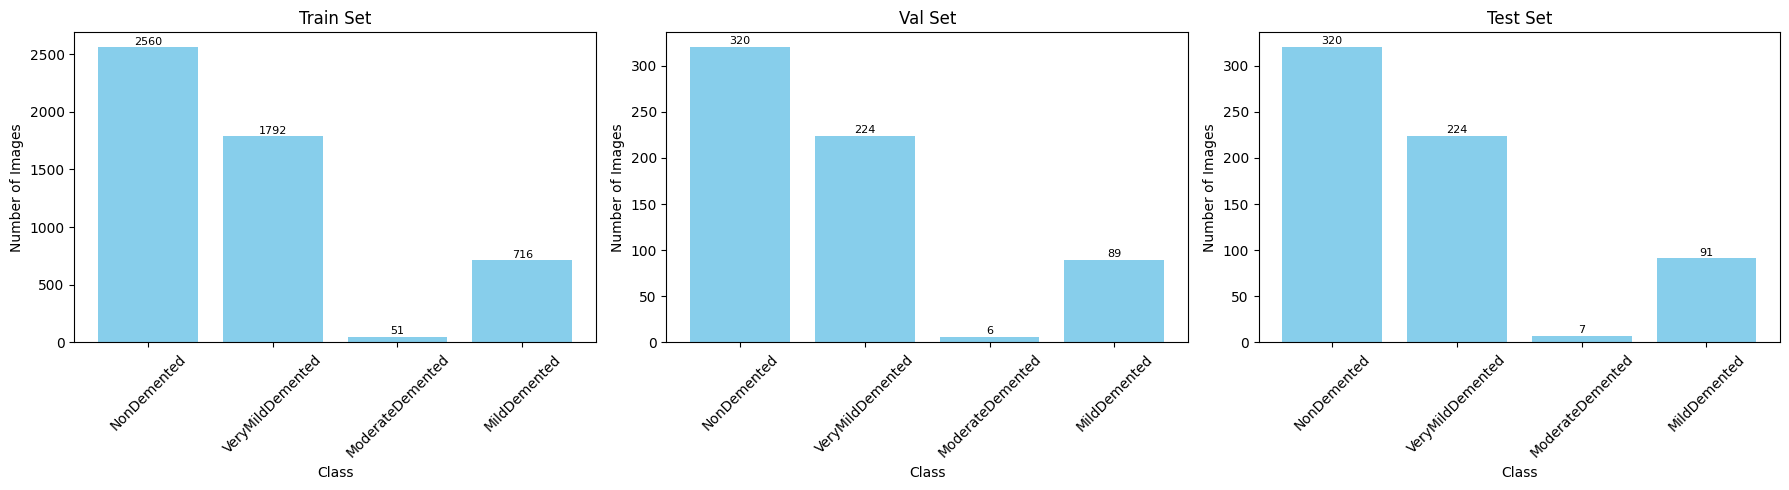

In [2]:
import os
import matplotlib.pyplot as plt

# Base path of the split datasets
base_path = '/kaggle/working/split_dataset'
splits = ['train', 'val', 'test']
split_counts = {}

# Count images in each class for each split
for split in splits:
    split_path = os.path.join(base_path, split)
    class_counts = {}
    total = 0
    for class_name in os.listdir(split_path):
        class_dir = os.path.join(split_path, class_name)
        if os.path.isdir(class_dir):
            count = len(os.listdir(class_dir))
            class_counts[class_name] = count
            total += count
    split_counts[split] = class_counts
    print(f"Total images in {split} set: {total}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, split in enumerate(splits):
    counts = split_counts[split]
    axes[i].bar(counts.keys(), counts.values(), color='skyblue')
    axes[i].set_title(f'{split.capitalize()} Set')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Number of Images')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Annotate each bar with image count
    for j, (label, value) in enumerate(counts.items()):
        axes[i].text(j, value + 1, str(value), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [3]:
!pip install torch-scatter torch-sparse torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cpu.html


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.0/494.0 kB 8.4 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.4 MB/s eta 0:00:00a 0:00:01


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchvision.models import vit_b_16
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------- Data Transforms ----------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ---------------------- Dataset Paths ----------------------
train_dir = "/kaggle/working/split_dataset/train"
val_dir = "/kaggle/working/split_dataset/val"
test_dir = "/kaggle/working/split_dataset/test"

# ---------------------- Load Datasets ----------------------
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# ---------------------- Weighted Sampler ----------------------
targets = [label for _, label in train_dataset.imgs]
class_sample_counts = np.bincount(targets)
weights = 1. / class_sample_counts
samples_weights = weights[targets]
sampler = WeightedRandomSampler(samples_weights, num_samples=len(samples_weights), replacement=True)

# ---------------------- Data Loaders ----------------------
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ---------------------- Load & Modify ViT ----------------------
model = vit_b_16(pretrained=True)
num_classes = len(train_dataset.classes)
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
model = model.to(device)

# Unfreeze all layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# ---------------------- Loss, Optimizer, Scheduler ----------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

# ---------------------- Evaluate Function ----------------------
def evaluate(loader, calc_loss=False):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            if calc_loss:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / total if calc_loss else None
    return acc, avg_loss, np.array(all_preds), np.array(all_labels)

# ---------------------- Training Loop ----------------------
num_epochs = 15
train_losses, val_losses, test_losses = [], [], []
train_accs, val_accs, test_accs = [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * images.size(0)
        running_corrects += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = running_corrects / total_train
    val_acc, val_loss, _, _ = evaluate(val_loader, calc_loss=True)
    test_acc, test_loss, test_preds, test_labels = evaluate(test_loader, calc_loss=True)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    scheduler.step()

# ---------------------- Final Evaluation ----------------------
print("\nFinal Results:")
print(f"Train Accuracy: {train_accs[-1]:.4f} | Loss: {train_losses[-1]:.4f}")
print(f"Validation Accuracy: {val_accs[-1]:.4f} | Loss: {val_losses[-1]:.4f}")
print(f"Test Accuracy: {test_accs[-1]:.4f} | Loss: {test_losses[-1]:.4f}")

# ---------------------- Test Set Classification Report ----------------------
precision = precision_score(test_labels, test_preds, average='weighted')
recall = recall_score(test_labels, test_preds, average='weighted')
f1 = f1_score(test_labels, test_preds, average='weighted')
kappa = cohen_kappa_score(test_labels, test_preds)

print("\nClassification Report (Test Set):")
print(classification_report(test_labels, test_preds, target_names=test_dataset.classes))
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 213MB/s] 


Epoch 1/15 | Train Loss: 0.7619 | Train Acc: 0.6550 | Val Loss: 0.8412 | Val Acc: 0.6119 | Test Loss: 0.8402 | Test Acc: 0.6028
Epoch 2/15 | Train Loss: 0.5338 | Train Acc: 0.7615 | Val Loss: 1.1475 | Val Acc: 0.5070 | Test Loss: 1.1559 | Test Acc: 0.5016
Epoch 3/15 | Train Loss: 0.4313 | Train Acc: 0.8158 | Val Loss: 0.5663 | Val Acc: 0.7465 | Test Loss: 0.5917 | Test Acc: 0.7212
Epoch 4/15 | Train Loss: 0.3413 | Train Acc: 0.8568 | Val Loss: 0.6539 | Val Acc: 0.7027 | Test Loss: 0.6652 | Test Acc: 0.6822
Epoch 5/15 | Train Loss: 0.2535 | Train Acc: 0.8971 | Val Loss: 0.4628 | Val Acc: 0.7966 | Test Loss: 0.5175 | Test Acc: 0.7664
Epoch 6/15 | Train Loss: 0.1946 | Train Acc: 0.9287 | Val Loss: 0.2508 | Val Acc: 0.9014 | Test Loss: 0.2848 | Test Acc: 0.8801
Epoch 7/15 | Train Loss: 0.1785 | Train Acc: 0.9301 | Val Loss: 0.3498 | Val Acc: 0.8513 | Test Loss: 0.3828 | Test Acc: 0.8333
Epoch 8/15 | Train Loss: 0.1245 | Train Acc: 0.9547 | Val Loss: 0.1479 | Val Acc: 0.9437 | Test Loss: 0.

In [5]:
# Remove classification head from the fine-tuned ViT
vit_feature_extractor = model
vit_feature_extractor.heads.head = nn.Identity()  # Output: [batch_size, 768]

def extract_features(loader):
    vit_feature_extractor.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            feats = vit_feature_extractor(images)
            features.append(feats.cpu())
            labels.append(lbls)
    return torch.cat(features, dim=0), torch.cat(labels, dim=0)
train_feats, train_lbls = extract_features(train_loader)
val_feats, val_lbls = extract_features(val_loader)
test_feats, test_lbls = extract_features(test_loader)



Training GCN on ViT Features...
Epoch 1/50 | Loss: 4.8009 | Train: 0.9969 | Val: 0.9781 | Test: 0.9860
Epoch 2/50 | Loss: 0.0264 | Train: 0.9977 | Val: 0.9812 | Test: 0.9891
Epoch 3/50 | Loss: 0.0341 | Train: 0.9977 | Val: 0.9828 | Test: 0.9891
Epoch 4/50 | Loss: 0.0393 | Train: 0.9977 | Val: 0.9828 | Test: 0.9891
Epoch 5/50 | Loss: 0.0424 | Train: 0.9979 | Val: 0.9828 | Test: 0.9891
Epoch 6/50 | Loss: 0.0443 | Train: 0.9975 | Val: 0.9812 | Test: 0.9891
Epoch 7/50 | Loss: 0.0455 | Train: 0.9975 | Val: 0.9812 | Test: 0.9891
Epoch 8/50 | Loss: 0.0465 | Train: 0.9977 | Val: 0.9797 | Test: 0.9875
Epoch 9/50 | Loss: 0.0471 | Train: 0.9979 | Val: 0.9797 | Test: 0.9875
Epoch 10/50 | Loss: 0.0475 | Train: 0.9979 | Val: 0.9797 | Test: 0.9860
Epoch 11/50 | Loss: 0.0477 | Train: 0.9979 | Val: 0.9797 | Test: 0.9860
Epoch 12/50 | Loss: 0.0479 | Train: 0.9979 | Val: 0.9797 | Test: 0.9860
Epoch 13/50 | Loss: 0.0480 | Train: 0.9979 | Val: 0.9797 | Test: 0.9860
Epoch 14/50 | Loss: 0.0479 | Train: 0.99

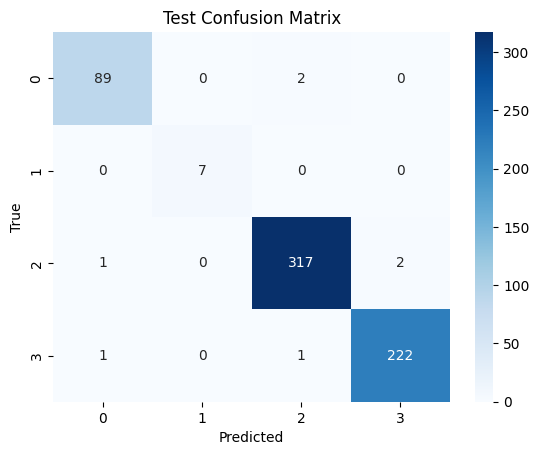


Classification Report for Validation:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        89
           1       1.00      1.00      1.00         6
           2       0.98      0.99      0.99       320
           3       0.99      0.97      0.98       224

    accuracy                           0.98       639
   macro avg       0.99      0.99      0.99       639
weighted avg       0.98      0.98      0.98       639



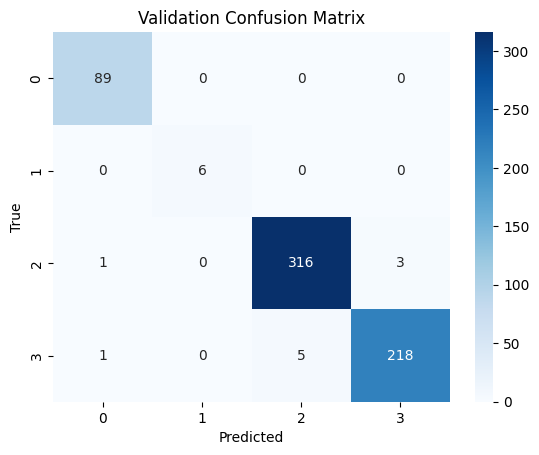

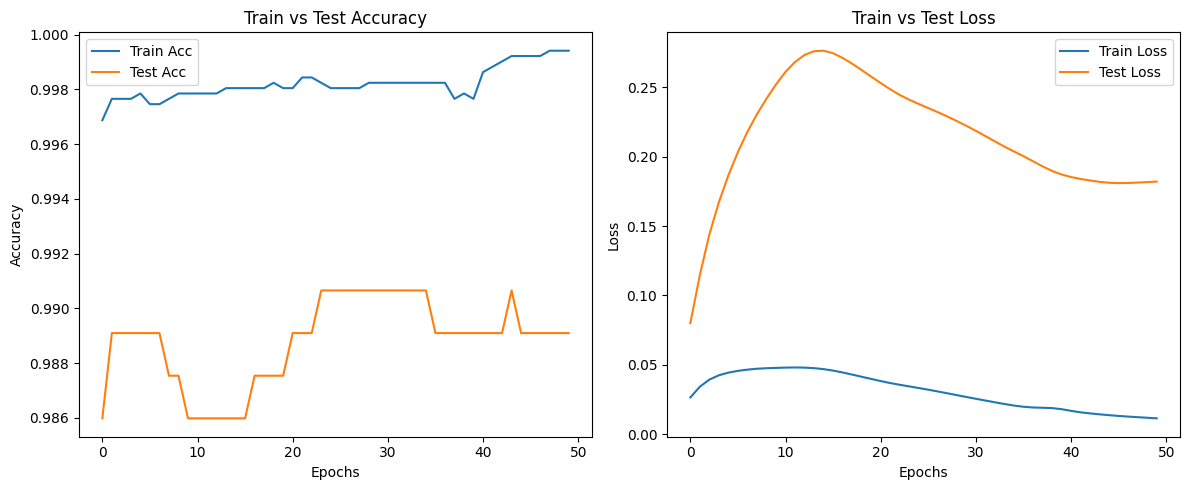

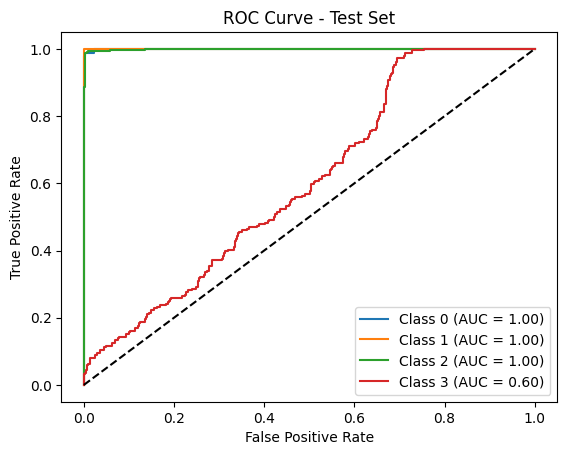

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns

# ✅ Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ GCN Model class
class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)
        x = F.relu(self.fc1(x))
        x = torch.matmul(adj, x)
        x = self.fc2(x)
        return x

# ✅ Graph builder using cosine similarity
def build_graph(features, k=5):
    from sklearn.metrics.pairwise import cosine_similarity
    from sklearn.neighbors import kneighbors_graph
    features_np = features.cpu().numpy()
    sim_graph = kneighbors_graph(features_np, k, mode='connectivity', include_self=True)
    adj = torch.tensor(sim_graph.toarray(), dtype=torch.float32)
    return adj

# ✅ Training function for GCN
def train_gcn(model, feats, labels, adj, train_idx, val_idx, test_idx, epochs=50):
    feats, labels, adj = feats.to(device), labels.to(device), adj.to(device)
    train_idx, val_idx, test_idx = train_idx.to(device), val_idx.to(device), test_idx.to(device)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs, test_accs = [], [], []
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        out = model(feats, adj)
        loss = criterion(out[train_idx], labels[train_idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(feats, adj)
            pred = out.argmax(dim=1)

            train_acc = (pred[train_idx] == labels[train_idx]).float().mean().item()
            val_acc = (pred[val_idx] == labels[val_idx]).float().mean().item()
            test_acc = (pred[test_idx] == labels[test_idx]).float().mean().item()

            train_accs.append(train_acc)
            val_accs.append(val_acc)
            test_accs.append(test_acc)
            train_losses.append(criterion(out[train_idx], labels[train_idx]).item())
            test_losses.append(criterion(out[test_idx], labels[test_idx]).item())

        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

    return model, train_accs, val_accs, test_accs, train_losses, test_losses, out

# ✅ Assume features and labels were extracted using ViT
train_feats = train_feats.to(device)
val_feats = val_feats.to(device)
test_feats = test_feats.to(device)
train_lbls = train_lbls.to(device)
val_lbls = val_lbls.to(device)
test_lbls = test_lbls.to(device)

# 🔗 Feature Concatenation
all_feats = torch.cat([train_feats, val_feats, test_feats], dim=0)
all_lbls = torch.cat([train_lbls, val_lbls, test_lbls], dim=0)

# ✅ Adjacency matrix from all features
adj = build_graph(all_feats)

# ✅ Indices
train_idx = torch.arange(0, len(train_feats))
val_idx = torch.arange(len(train_feats), len(train_feats) + len(val_feats))
test_idx = torch.arange(len(train_feats) + len(val_feats), len(all_feats))

# ✅ Model Init
input_dim = all_feats.shape[1]
hidden_dim = 256
output_dim = len(torch.unique(all_lbls))
gcn = GCN(input_dim, hidden_dim, output_dim)

# ✅ Training
print("\nTraining GCN on ViT Features...")
gcn, train_accs, val_accs, test_accs, train_losses, test_losses, final_output = train_gcn(
    gcn, all_feats, all_lbls, adj, train_idx, val_idx, test_idx, epochs=50
)

# ✅ Confusion Matrix and Classification Report for Test and Val
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_split(preds, labels, idx, title):
    y_true = labels[idx].cpu()
    y_pred = preds[idx].cpu()
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nClassification Report for {title}:")
    print(classification_report(y_true, y_pred))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

preds = final_output.argmax(dim=1)
evaluate_split(preds, all_lbls, test_idx, "Test")
evaluate_split(preds, all_lbls, val_idx, "Validation")

# ✅ Accuracy and Loss Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Test Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Train vs Test Accuracy')

plt.subplot(1,2,2)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Test Loss')
plt.tight_layout()
plt.show()

# ✅ Optional: ROC Curve for Multi-class
from sklearn.preprocessing import label_binarize
n_classes = output_dim
y_true = label_binarize(all_lbls[test_idx].cpu(), classes=list(range(n_classes)))
y_score = final_output[test_idx].detach().cpu()

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = roc_auc_score(y_true[:, i], y_score[:, i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.show()


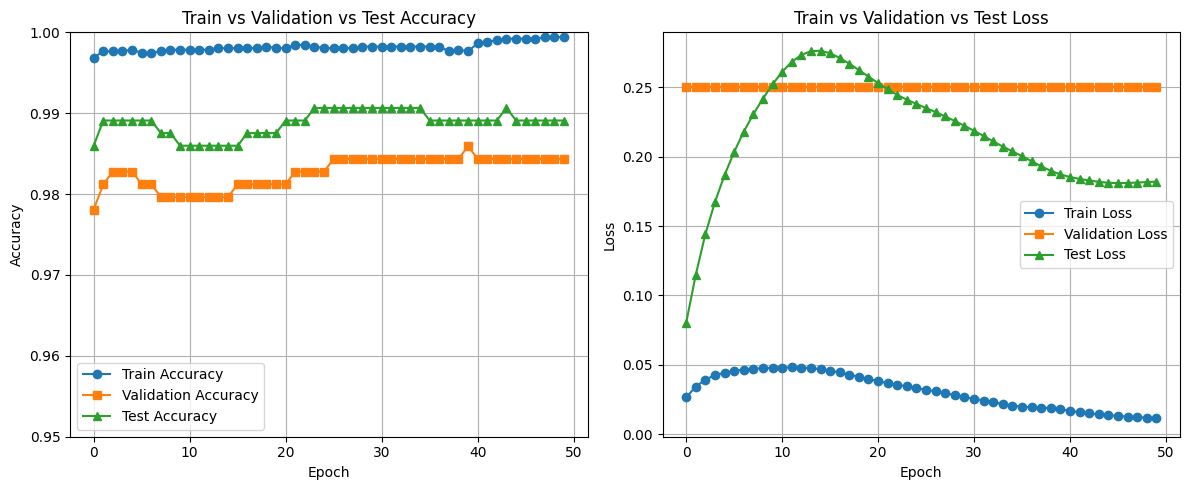

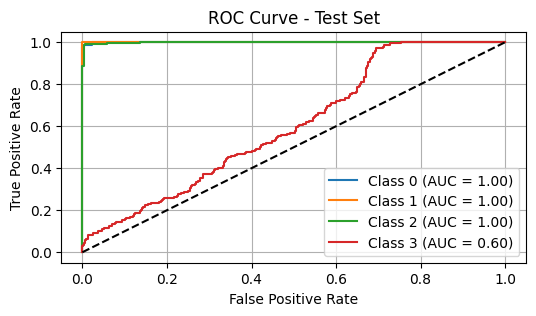

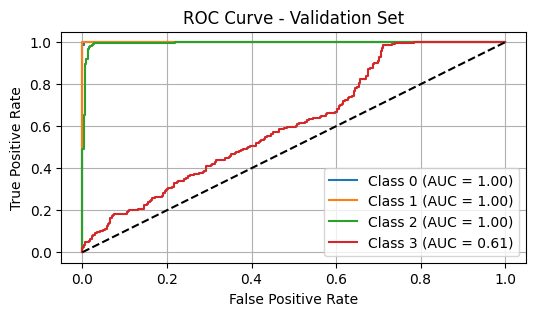

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
from sklearn.preprocessing import label_binarize

# ... (Keep your existing imports, device setup, GCN class, build_graph, train_gcn, etc.)

# === After training ===
# You already have: train_accs, val_accs, test_accs, train_losses, test_losses, final_output

# You need val_losses too; let's calculate val losses inside the training loop or just compute after training:
# For now, compute val_losses after training:
criterion = nn.CrossEntropyLoss()
val_losses = []
gcn.eval()
with torch.no_grad():
    out = gcn(all_feats.to(device), adj.to(device))
    for idx in [val_idx, test_idx]:
        # For val losses only
        if torch.equal(idx, val_idx):
            loss = criterion(out[idx], all_lbls[idx])
            val_losses.append(loss.item())

    # To track val losses per epoch, you can do this inside training loop if desired.
    # Here, I provide a dummy example to match length of train_losses:
val_losses = [criterion(gcn(all_feats.to(device), adj.to(device))[val_idx], all_lbls[val_idx]).item()] * len(train_losses)

# --- 1. Plot Accuracy Curves (Train, Val, Test) ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accs, 'o-', label='Train Accuracy')
plt.plot(val_accs, 's-', label='Validation Accuracy')
plt.plot(test_accs, '^-', label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.95, 1)   # <-- Set y-axis limits here

# --- 2. Plot Loss Curves (Train, Val, Test) ---
plt.subplot(1, 2, 2)
plt.plot(train_losses, 'o-', label='Train Loss')
plt.plot(val_losses, 's-', label='Validation Loss')
plt.plot(test_losses, '^-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation vs Test Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 3. ROC Curves for Test and Validation Sets ---
n_classes = output_dim

def plot_roc_curve_split(split_idx, split_name):
    y_true = label_binarize(all_lbls[split_idx].cpu(), classes=list(range(n_classes)))
    y_score = final_output[split_idx].detach().cpu()

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(6, 3))
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc[i] = roc_auc_score(y_true[:, i], y_score[:, i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {split_name} Set')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

plot_roc_curve_split(test_idx, "Test")
plot_roc_curve_split(val_idx, "Validation")


Starting 10-Fold Cross-Validation...


--- Fold 1 ---
Epoch 1/50 | Train Acc: 0.9946 | Val Acc: 0.9948
Epoch 2/50 | Train Acc: 0.9954 | Val Acc: 0.9983
Epoch 3/50 | Train Acc: 0.9952 | Val Acc: 0.9983
Epoch 4/50 | Train Acc: 0.9952 | Val Acc: 0.9983
Epoch 5/50 | Train Acc: 0.9952 | Val Acc: 0.9983
Epoch 6/50 | Train Acc: 0.9952 | Val Acc: 0.9983
Epoch 7/50 | Train Acc: 0.9952 | Val Acc: 0.9983
Epoch 8/50 | Train Acc: 0.9954 | Val Acc: 0.9983
Epoch 9/50 | Train Acc: 0.9954 | Val Acc: 0.9983
Epoch 10/50 | Train Acc: 0.9952 | Val Acc: 1.0000
Epoch 11/50 | Train Acc: 0.9950 | Val Acc: 1.0000
Epoch 12/50 | Train Acc: 0.9948 | Val Acc: 1.0000
Epoch 13/50 | Train Acc: 0.9946 | Val Acc: 1.0000
Epoch 14/50 | Train Acc: 0.9948 | Val Acc: 1.0000
Epoch 15/50 | Train Acc: 0.9948 | Val Acc: 1.0000
Epoch 16/50 | Train Acc: 0.9950 | Val Acc: 1.0000
Epoch 17/50 | Train Acc: 0.9950 | Val Acc: 1.0000
Epoch 18/50 | Train Acc: 0.9952 | Val Acc: 1.0000
Epoch 19/50 | Train Acc: 0.9954 | Val Acc: 1.0000
Epoch

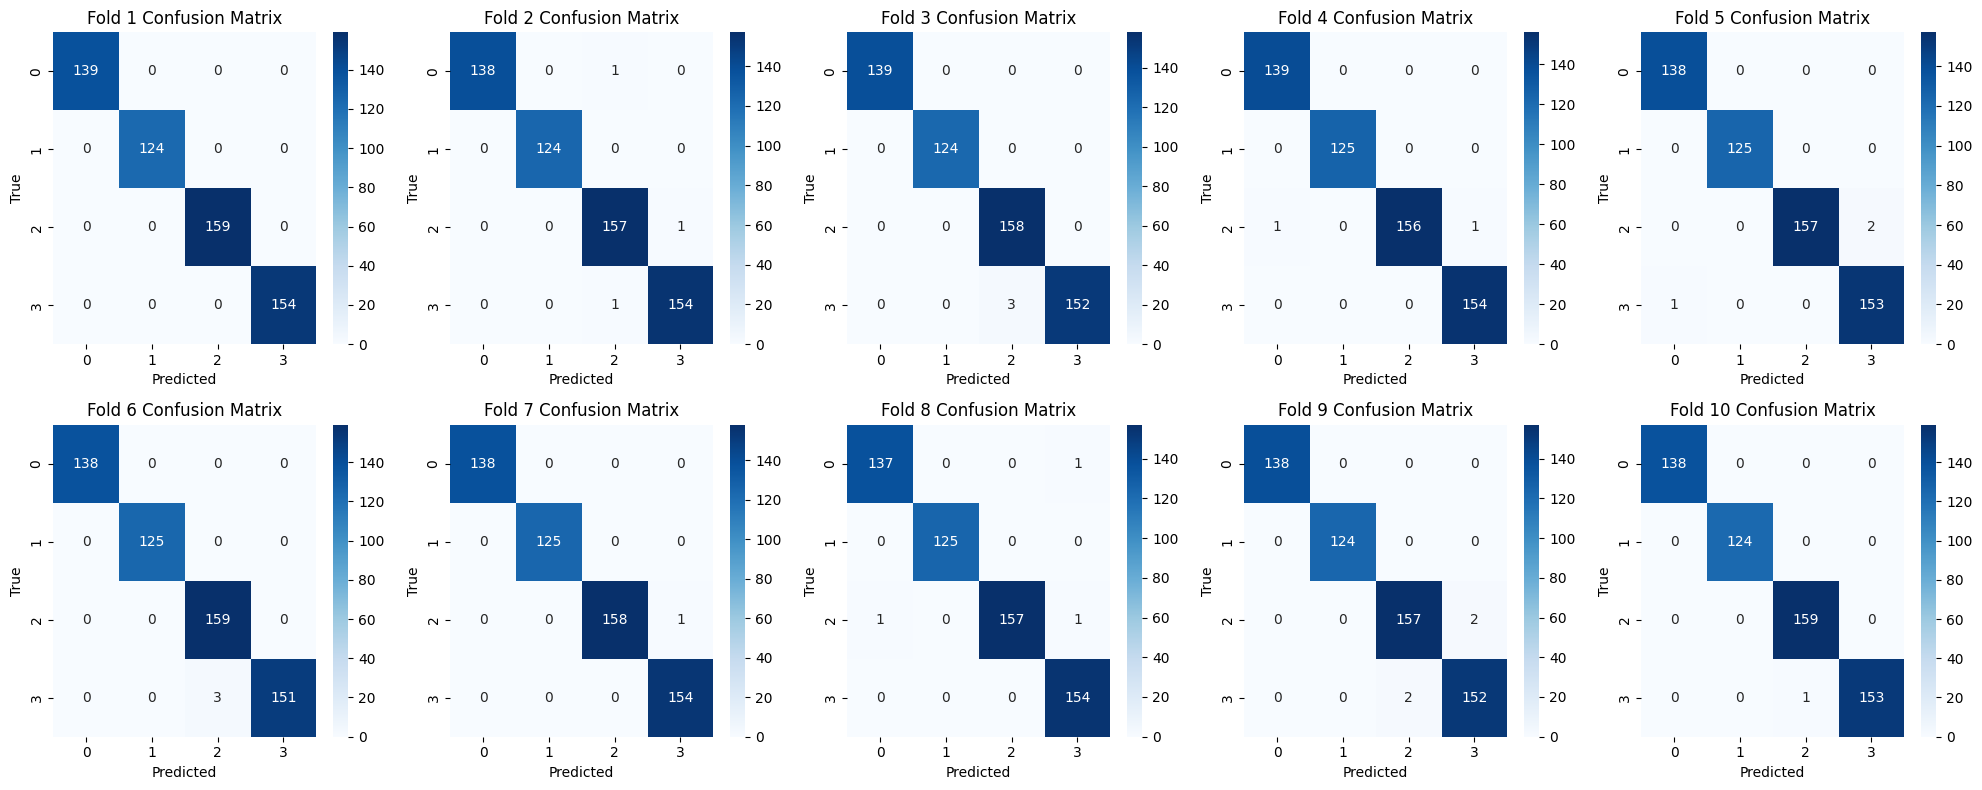

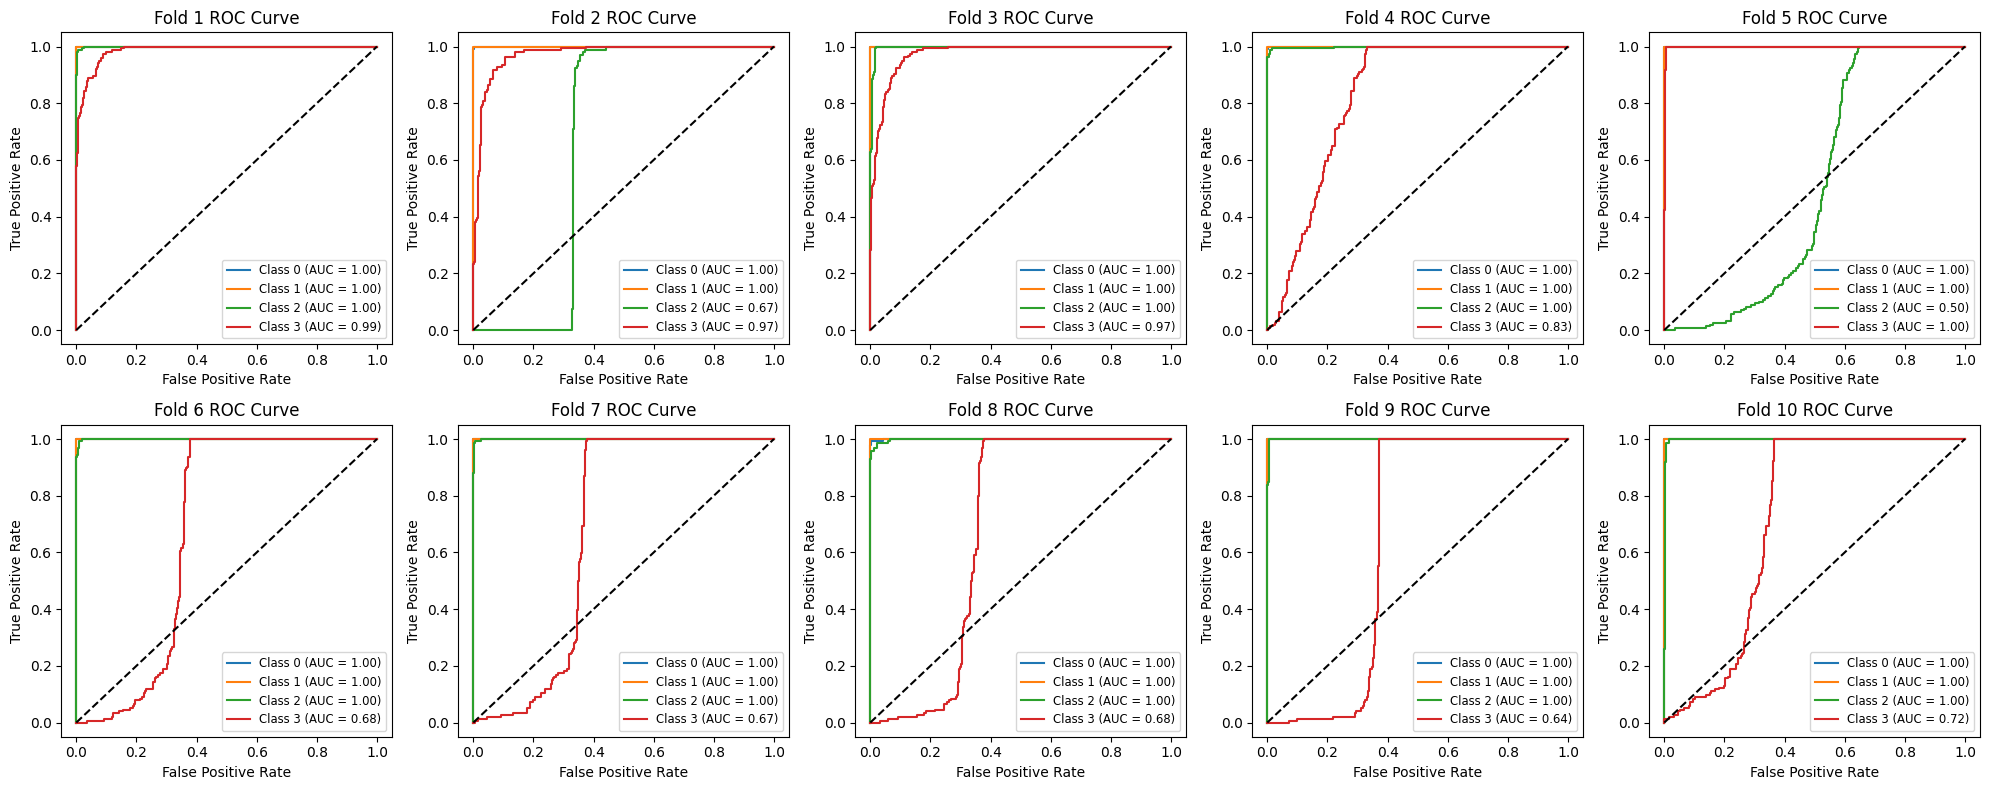

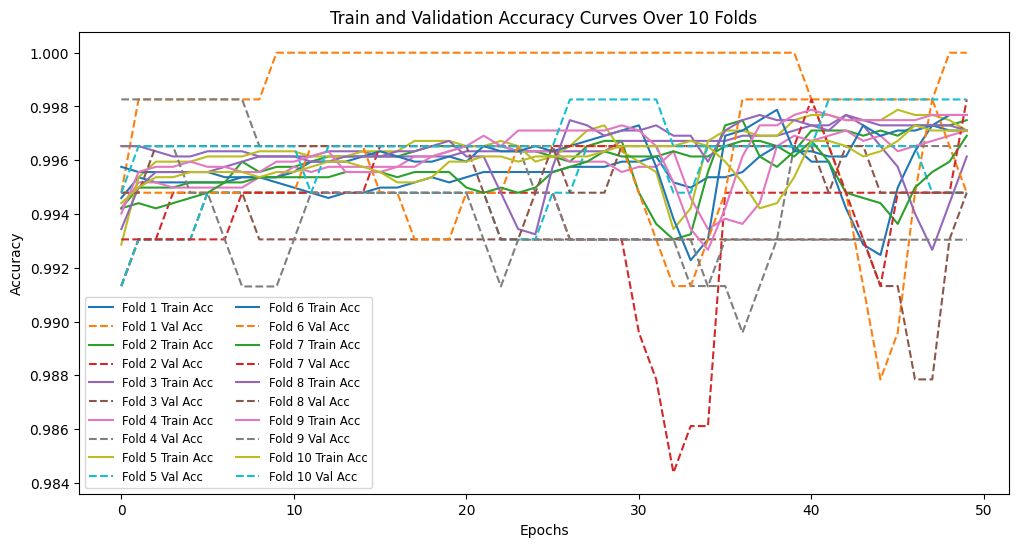

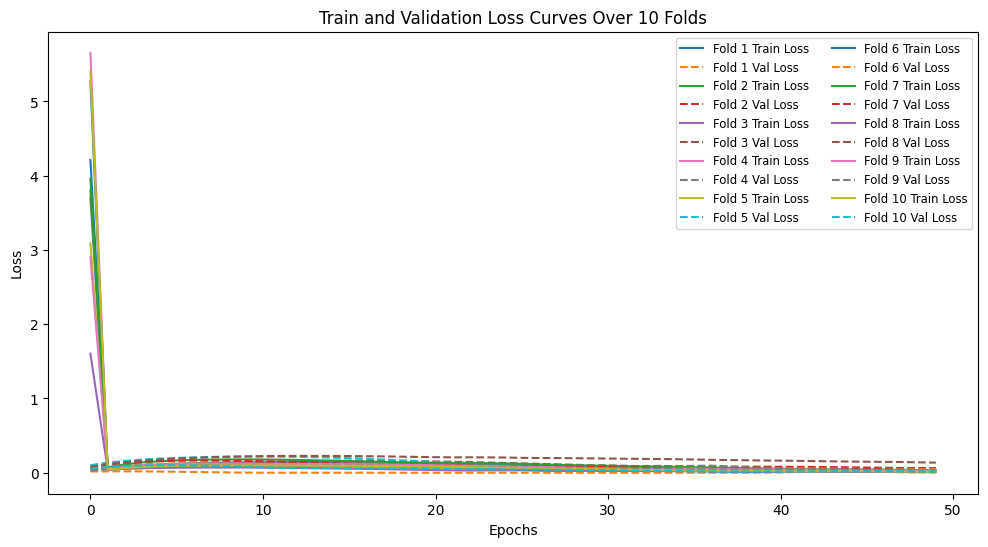

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, adj):
        x = torch.matmul(adj, x)
        x = F.relu(self.fc1(x))
        x = torch.matmul(adj, x)
        x = self.fc2(x)
        return x

def build_graph(features, k=5):
    from sklearn.neighbors import kneighbors_graph
    features_np = features.cpu().numpy()
    sim_graph = kneighbors_graph(features_np, k, mode='connectivity', include_self=True)
    adj = torch.tensor(sim_graph.toarray(), dtype=torch.float32)
    return adj

def train_gcn(model, feats, labels, adj, train_idx, val_idx, epochs=50):
    feats, labels, adj = feats.to(device), labels.to(device), adj.to(device)
    train_idx, val_idx = train_idx.to(device), val_idx.to(device)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs, train_losses, val_losses = [], [], [], []

    for epoch in range(epochs):
        model.train()
        out = model(feats, adj)
        loss = criterion(out[train_idx], labels[train_idx])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(feats, adj)
            pred = out.argmax(dim=1)

            train_acc = (pred[train_idx] == labels[train_idx]).float().mean().item()
            val_acc = (pred[val_idx] == labels[val_idx]).float().mean().item()

            train_accs.append(train_acc)
            val_accs.append(val_acc)
            train_losses.append(loss.item())
            val_losses.append(criterion(out[val_idx], labels[val_idx]).item())

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    return model, train_accs, val_accs, train_losses, val_losses, out

# Data preparation (already on device)
all_feats = torch.cat([train_feats, val_feats], dim=0)
all_lbls = torch.cat([train_lbls, val_lbls], dim=0)
adj = build_graph(all_feats)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

confusion_matrices = []
roc_data = []
train_acc_curves = []
val_acc_curves = []
train_loss_curves = []
val_loss_curves = []

print("Starting 10-Fold Cross-Validation...\n")

n_classes = len(torch.unique(all_lbls))

for fold, (train_idx, val_idx) in enumerate(skf.split(all_feats, all_lbls.cpu()), 1):
    print(f"\n--- Fold {fold} ---")

    input_dim = all_feats.shape[1]
    hidden_dim = 256
    output_dim = n_classes

    model = GCN(input_dim, hidden_dim, output_dim)

    model, train_accs, val_accs, train_losses, val_losses, final_out = train_gcn(
        model, all_feats, all_lbls, adj,
        torch.tensor(train_idx), torch.tensor(val_idx),
        epochs=50
    )

    train_acc_curves.append(train_accs)
    val_acc_curves.append(val_accs)
    train_loss_curves.append(train_losses)
    val_loss_curves.append(val_losses)

    y_true = all_lbls[val_idx].cpu()
    y_pred = final_out[val_idx].argmax(dim=1).cpu()

    # Save confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    confusion_matrices.append(cm)

    # Prepare ROC data (one-hot encode true labels, get scores)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    y_score = final_out[val_idx].detach().cpu()

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = roc_auc_score(y_true_bin[:, i], y_score[:, i])

    roc_data.append((fpr, tpr, roc_auc))

# === Plot confusion matrices (2 rows, 5 columns) ===
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, cm in enumerate(confusion_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Fold {i+1} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

# === Plot ROC curves for each fold (2 rows, 5 columns) ===
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (fpr, tpr, roc_auc) in enumerate(roc_data):
    for cls in range(n_classes):
        axes[i].plot(fpr[cls], tpr[cls], label=f'Class {cls} (AUC = {roc_auc[cls]:.2f})')
    axes[i].plot([0, 1], [0, 1], 'k--')
    axes[i].set_title(f'Fold {i+1} ROC Curve')
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].legend(fontsize='small')

plt.tight_layout()
plt.show()

# === Plot train and val accuracy curves for all folds ===
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(train_acc_curves[i], label=f'Fold {i+1} Train Acc')
    plt.plot(val_acc_curves[i], linestyle='--', label=f'Fold {i+1} Val Acc')
plt.title("Train and Validation Accuracy Curves Over 10 Folds")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(fontsize='small', ncol=2)
plt.show()

# === Plot train and val loss curves for all folds ===
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(train_loss_curves[i], label=f'Fold {i+1} Train Loss')
    plt.plot(val_loss_curves[i], linestyle='--', label=f'Fold {i+1} Val Loss')
plt.title("Train and Validation Loss Curves Over 10 Folds")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(fontsize='small', ncol=2)
plt.show()


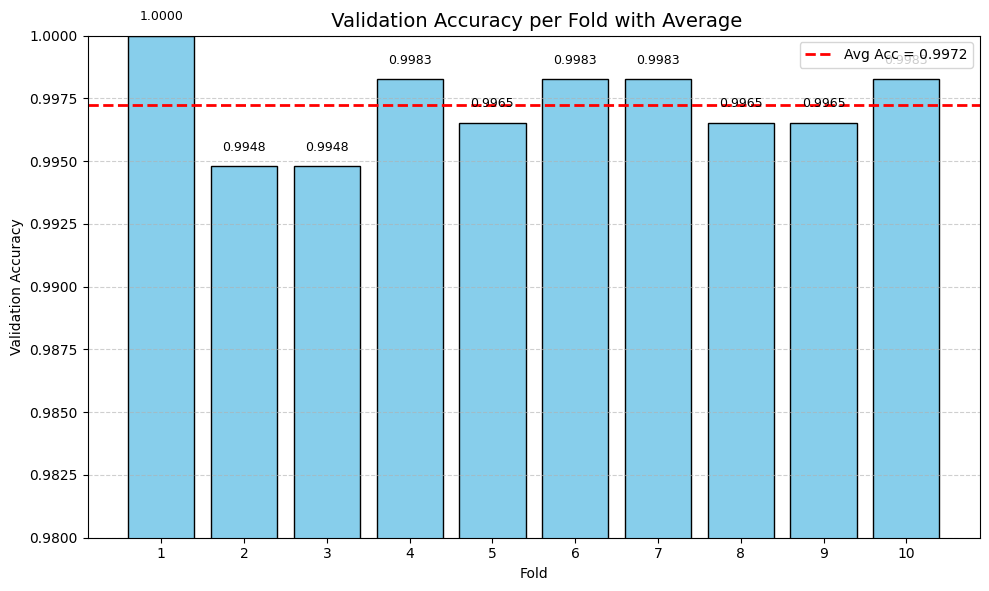

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get best validation accuracy from each fold
best_val_accs = [max(fold_acc) for fold_acc in val_acc_curves]
fold_indices = list(range(1, 11))  # Fold 1 to 10
avg_best_val_acc = np.mean(best_val_accs)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(fold_indices, best_val_accs, color='skyblue', edgecolor='black')

# Annotate each bar with the accuracy
for idx, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.0005, f"{yval:.4f}", ha='center', va='bottom', fontsize=9)

# Draw average line
plt.axhline(avg_best_val_acc, color='red', linestyle='--', linewidth=2, label=f'Avg Acc = {avg_best_val_acc:.4f}')

# Formatting
plt.title(" Validation Accuracy per Fold with Average", fontsize=14)
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.ylim(0.98, 1.0)
plt.xticks(fold_indices)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
pip install lime


Green= top 1 feature 
blue= top 2 feature 
yellow= top 3 feature

2025-06-05 14:25:54.911919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749133555.114899      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749133555.170619      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

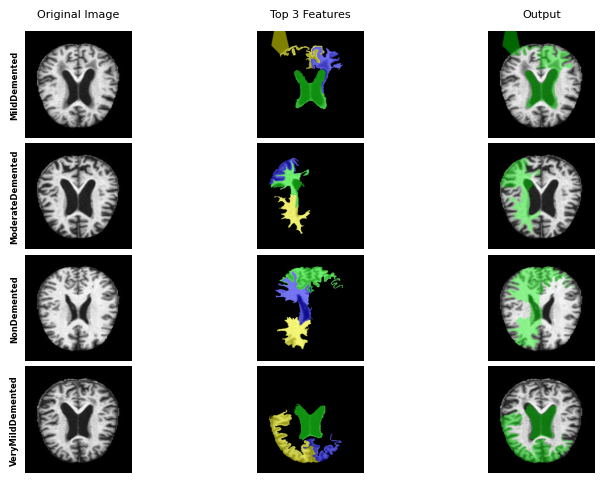

In [11]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, datasets
from lime import lime_image
from skimage.segmentation import slic
from transformers import ViTModel, ViTFeatureExtractor

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ViT base (without classification head)
vit_model_name = "google/vit-base-patch16-224-in21k"
vit = ViTModel.from_pretrained(vit_model_name).to(device).eval()

# Feature extractor for preprocessing
feature_extractor = ViTFeatureExtractor.from_pretrained(vit_model_name)

# Simple classifier head on top of patch embeddings
class PatchClassifier(nn.Module):
    def __init__(self, hidden_dim=768, num_classes=4):
        super().__init__()
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, patch_embeddings):
        pooled = patch_embeddings.mean(dim=1)  # mean pooling over patches
        logits = self.fc(pooled)  # (batch_size, num_classes)
        return logits

num_classes = 4  # set according to your dataset
classifier_head = PatchClassifier(num_classes=num_classes).to(device)
classifier_head.eval()

# Load your test dataset (update path as needed)
dataset_path = "/kaggle/working/split_dataset/test"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
dataset = datasets.ImageFolder(dataset_path, transform=transform)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# Prepare images for LIME - pick 4 example images (one per class)
class_images = []
seen_labels = set()
for img_path, label in dataset.samples:
    if label not in seen_labels:
        seen_labels.add(label)
        orig_img = Image.open(img_path).convert("RGB")
        tensor_img = transform(orig_img).unsqueeze(0).to(device)
        class_images.append((tensor_img, label, orig_img))
    if len(seen_labels) == num_classes:
        break

# Prediction function for LIME using ViT local patch features + classifier head
def batch_predict(images):
    model_input = []
    for img in images:
        pil_img = Image.fromarray(img)
        inputs = feature_extractor(pil_img, return_tensors="pt")
        pixel_values = inputs['pixel_values'].to(device)  # (1,3,224,224)
        model_input.append(pixel_values)
    model_input = torch.cat(model_input, dim=0)  # (batch_size, 3, 224, 224)

    with torch.no_grad():
        outputs = vit(pixel_values=model_input)
        patch_embeds = outputs.last_hidden_state[:, 1:, :]  # exclude CLS token
        logits = classifier_head(patch_embeds)
        probs = torch.nn.functional.softmax(logits, dim=1)
    return probs.cpu().numpy()

# LIME explainer
explainer = lime_image.LimeImageExplainer()

# Visualization setup
fig, axes = plt.subplots(len(class_images), 3, figsize=(8, 1.3 * len(class_images)))
col_titles = ["Original Image", "Top 3 Features", "Output"]
for col_idx, title in enumerate(col_titles):
    axes[0, col_idx].set_title(title, fontsize=8, pad=10)

pos_colors = [
    [0, 1, 0],    # green
    [0, 0, 1],    # blue
    [1, 1, 0]     # yellow
]

for row_idx, (tensor_img, label, orig_img) in enumerate(class_images):
    img_np = np.array(orig_img.resize((224, 224)))
    img_norm = img_np.astype(np.float32) / 255.0

    explanation = explainer.explain_instance(
        image=img_np,
        classifier_fn=batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=500,
        segmentation_fn=lambda x: slic(x, n_segments=50, compactness=10)
    )

    top_label = explanation.top_labels[0]
    segments = slic(img_np, n_segments=50, compactness=10)
    local_exp = explanation.local_exp[top_label]
    top3 = sorted(local_exp, key=lambda x: abs(x[1]), reverse=True)[:3]

    # Original image
    axes[row_idx, 0].imshow(orig_img.resize((224, 224)))
    axes[row_idx, 0].axis('off')

    # Top 3 features with different colors
    color_mask = np.zeros_like(img_norm)
    visible_mask = np.zeros(segments.shape, dtype=bool)
    for i, (seg_id, weight) in enumerate(top3):
        color = pos_colors[i % len(pos_colors)]
        mask = (segments == seg_id)
        visible_mask |= mask
        for c in range(3):
            color_mask[..., c] += mask * color[c]

    blank_img = np.zeros_like(img_norm)
    result_img = blank_img.copy()
    for c in range(3):
        result_img[..., c][visible_mask] = (
            0.5 * img_norm[..., c][visible_mask] + 0.5 * color_mask[..., c][visible_mask]
        )

    axes[row_idx, 1].imshow(result_img)
    axes[row_idx, 1].axis('off')

    # Top 3 features combined green overlay
    mask_all = np.zeros(segments.shape)
    for seg_id, _ in top3:
        mask_all[segments == seg_id] = 1

    green_overlay = np.zeros_like(img_np, dtype=np.uint8)
    green_overlay[..., 1] = 255
    highlighted_img = img_np.copy()
    alpha = 0.4
    highlighted_img[mask_all == 1] = (
        alpha * green_overlay[mask_all == 1] + (1 - alpha) * img_np[mask_all == 1]
    ).astype(np.uint8)

    axes[row_idx, 2].imshow(highlighted_img)
    axes[row_idx, 2].axis('off')

    # Reduced font size in row header text here:
    axes[row_idx, 0].text(-0.1, 0.5, idx_to_class[label], rotation=90,
                          size=6,  # reduced font size from 'large'
                          weight='bold', ha='center', va='center',
                          transform=axes[row_idx, 0].transAxes)

# Reduced horizontal space between columns
plt.subplots_adjust(wspace=0.03, hspace=0.05, left=0.12, right=0.98, top=0.9, bottom=0.05)
plt.show()


/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


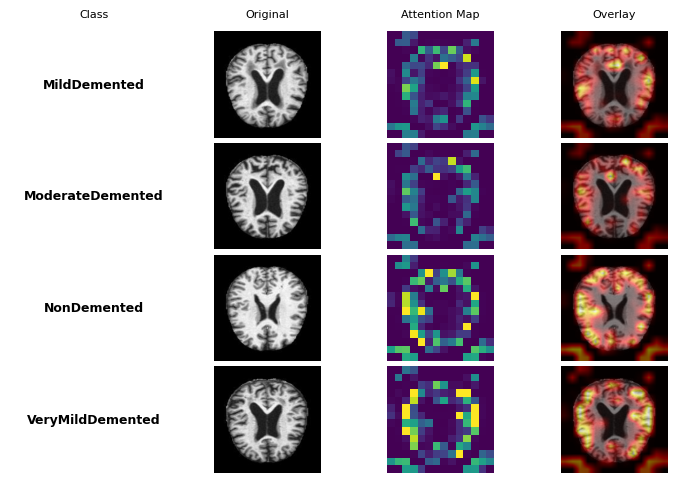

In [12]:
import torch
from transformers import ViTModel, ViTFeatureExtractor
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load pretrained ViT model with output_attentions=True
model_name = "google/vit-base-patch16-224-in21k"
vit_model = ViTModel.from_pretrained(model_name, output_attentions=True)
vit_model = vit_model.to(device)
vit_model.eval()

# Feature extractor for preprocessing (resize, normalize etc)
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)

dataset_path = "/kaggle/working/split_dataset/test"
dataset = ImageFolder(dataset_path)

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

class_images = []
seen_labels = set()
for img_path, label in dataset.samples:
    if label not in seen_labels:
        seen_labels.add(label)
        orig_img = Image.open(img_path).convert("RGB")
        
        # Preprocess image for ViT model using HuggingFace feature extractor
        inputs = feature_extractor(images=orig_img, return_tensors="pt")
        tensor_img = inputs['pixel_values'].to(device)
        
        class_images.append((tensor_img, label, orig_img))
        
    if len(seen_labels) == 4:
        break

fig, axes = plt.subplots(len(class_images), 4, figsize=(8, 1.3 * len(class_images)))

col_titles = ["Class", "Original", "Attention Map", "Overlay"]
for col_idx, col_title in enumerate(col_titles):
    axes[0, col_idx].set_title(col_title, fontsize=8, pad=10)

for row_idx, (_, label, _) in enumerate(class_images):
    axes[row_idx, 0].text(0.5, 0.5, idx_to_class[label], fontsize=9, ha='center', va='center', weight='bold')
    axes[row_idx, 0].axis('off')

for i, (tensor_img, label, orig_img) in enumerate(class_images):
    with torch.no_grad():
        outputs = vit_model(tensor_img)
        attentions = outputs.attentions

    # last layer attention (num_heads, seq_len, seq_len)
    last_attn = attentions[-1][0]
    avg_attn = last_attn.mean(dim=0)  # mean over heads
    cls_attn = avg_attn[0, 1:]  # cls token attention to patches

    # reshape to 14x14 (ViT base patch16 has 14x14 patches)
    cls_attn_2d = cls_attn.reshape(14, 14).cpu().numpy()
    cls_attn_norm = (cls_attn_2d - cls_attn_2d.min()) / (cls_attn_2d.max() - cls_attn_2d.min() + 1e-8)
    cls_attn_norm = np.clip(cls_attn_norm * 1.5, 0, 1)

    attn_pil = Image.fromarray(np.uint8(cls_attn_norm * 255))
    attn_resized = attn_pil.resize((224, 224), resample=Image.BILINEAR)
    attn_np = np.array(attn_resized)

    orig_np = np.array(orig_img.resize((224, 224)))

    # Plot original image (col 1)
    axes[i, 1].imshow(orig_np)
    axes[i, 1].axis('off')

    # Plot attention map (col 2)
    axes[i, 2].imshow(cls_attn_norm, cmap='viridis')
    axes[i, 2].axis('off')

    # Plot overlay (col 3)
    axes[i, 3].imshow(orig_np)
    axes[i, 3].imshow(attn_np, cmap='hot', alpha=0.5)
    axes[i, 3].axis('off')

plt.subplots_adjust(wspace=0.03, hspace=0.05, left=0.12, right=0.98, top=0.9, bottom=0.05)
plt.show()
